In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
image_directory = "drive/MyDrive/Faulty_solar_panel"

Mounted at /content/drive/


In [ ]:
import tensorflow as tf
import numpy as np
import os
from cv2 import imread, resize
from google.colab.patches import cv2_imshow as imshow
from time import time

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "training",
    seed = np.random.randint(1, 10000),
    image_size = (224, 224),
    batch_size = 32
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_directory,
    validation_split = 0.2,
    subset = "validation",
    seed = np.random.randint(1, 10000),
    image_size = (224, 224),
    batch_size = 32
)
class_names = train_ds.class_names

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
model = tf.keras.models.load_model(
    'drive/MyDrive/best_model.keras',
    custom_objects = {'softmax_v2': tf.nn.softmax}
    )

Mounted at /content/drive/

The Test Image:



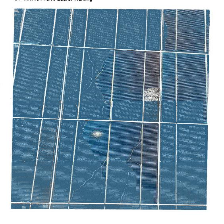

In [ ]:
drive.mount('/content/drive/', force_remount = True)  # Force remount for redundancy, incase image changes after running once
files = [f for f in os.listdir(image_directory) if os.path.isfile(os.path.join(image_directory, f))]
if(len(files) == 0):
  raise Exception("Error in loading the image.")
image = imread(os.path.join(image_directory, files[0]))
image = resize(image, (224, 224))
print("\nThe Test Image:\n")
imshow(image)

In [ ]:
start = time()
prediction = model.predict(tf.expand_dims(image, 0), verbose = 0)
print("Prediction:", class_names[np.argmax(prediction)])
print(f"\nTime taken to make prediction: {(time() - start):.2f} seconds.")

Prediction: Electrical-damage

Time taken to make prediction: 0.15 seconds.
